In [1]:
!pip install --upgrade --force-reinstall --no-deps kaggle

  Using cached kaggle-2.1.0-py3-none-any.whl.metadata (16 kB)
Using cached kaggle-2.1.0-py3-none-any.whl (95 kB)
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.1.0
    Uninstalling kaggle-2.1.0:
      Successfully uninstalled kaggle-2.1.0



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\sally\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\sally\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\sally\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!python -m pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\sally\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

(27455, 50)
Total Explained Variance: 0.8874


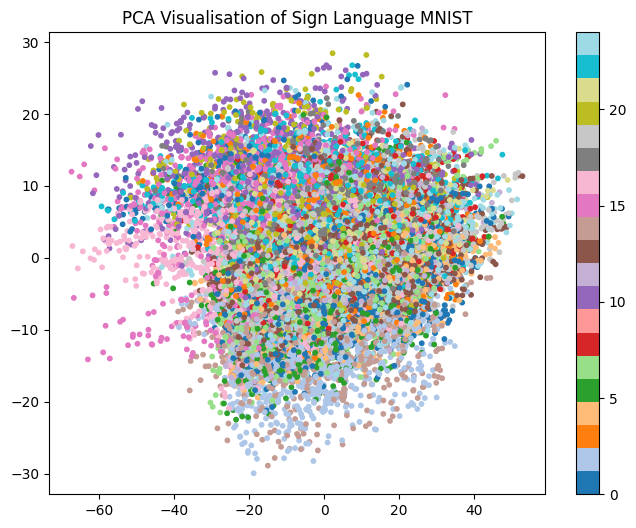

In [6]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("archive/sign_mnist_train/sign_mnist_train.csv")
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"Total Explained Variance: {explained_variance:.4f}")

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap='tab20', s=10)
plt.colorbar()
plt.title("PCA Visualisation of Sign Language MNIST")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


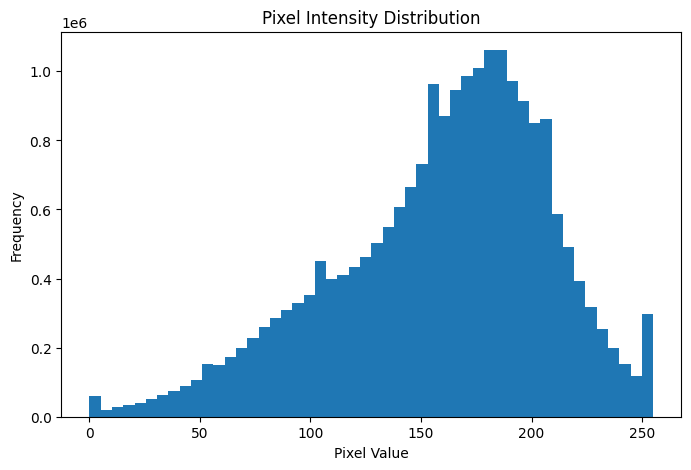

In [7]:
plt.figure(figsize=(8,5))
plt.hist(X.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\sally\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


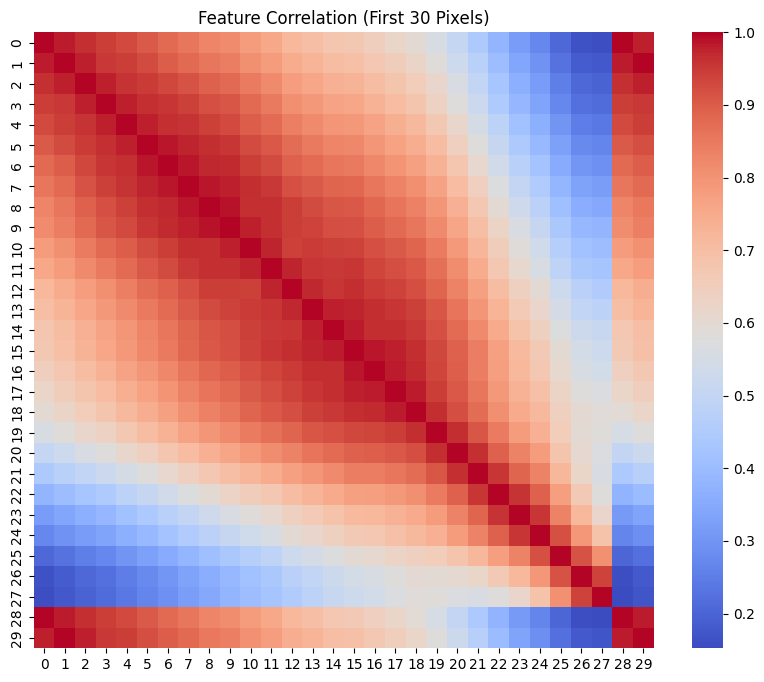

In [ ]:
!pip install seaborn
import seaborn as sns

corr = pd.DataFrame(X[:, :30]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation (First 30 Pixels)")
plt.show() # feature corr not very useful

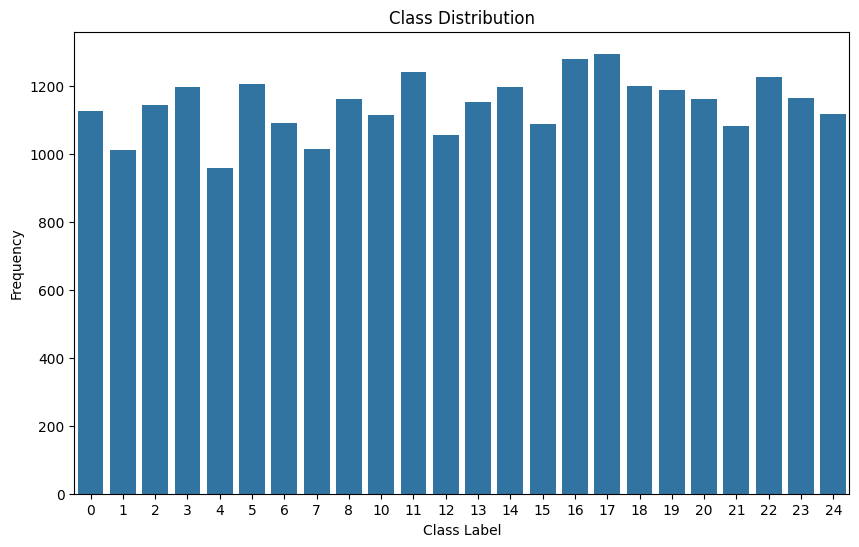

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Frequency") #classes fairly equal
plt.show()

In [8]:
# Dataset description for Sign Language MNIST


print(f"Number of samples: {train_df.shape[0]}")
print(f"Number of pixels: {train_df.shape[1] - 1}")
print(f"Image resolution: 28x28 grayscale images flattened into vectors of length 784")
print(f"Number of classes: {len(np.unique(y))}")

print("\n===Class Distribution ===")
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

print("\n=== Sample Feature Range ===")
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")

print("\n===Label Info===")
print("Labels correspond to ASL hand signs (A-Z, excluding J and Z due to motion-based signs).")

print("\n===Data Type Info===")
print(train_df.dtypes)

print("\n=== Missing Values Check ===")
print(train_df.isnull().sum().sum(), "missing values in dataset")

Number of samples: 27455
Number of pixels: 784
Image resolution: 28x28 grayscale images flattened into vectors of length 784
Number of classes: 24

===Class Distribution ===
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

=== Sample Feature Range ===
Min pixel value: 0
Max pixel value: 255

===Label Info===
Labels correspond to ASL hand signs (A-Z, excluding J and Z due to motion-based signs).

===Data Type Info===
label       int64
pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 785, dtype: object

=== Missing Values Check ===
0 missing values in dataset


In [9]:
clf = LogisticRegression(max_iter=1000)
clf = SVC(kernel="rbf")
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.9974503733381898


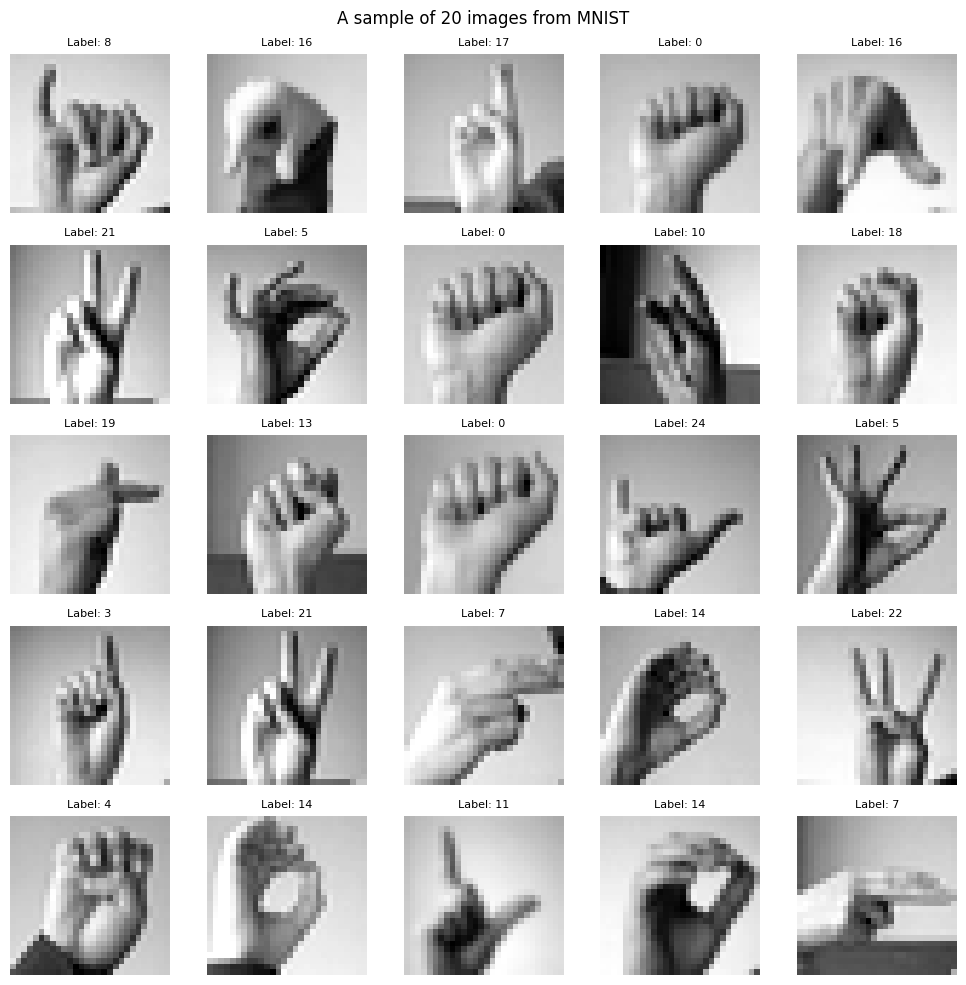

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

indices = np.random.choice(len(X), 25, replace=False)

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[idx]}", fontsize=8)
    ax.axis("off")

plt.suptitle("A sample of 20 images from MNIST")
plt.tight_layout()
plt.show()

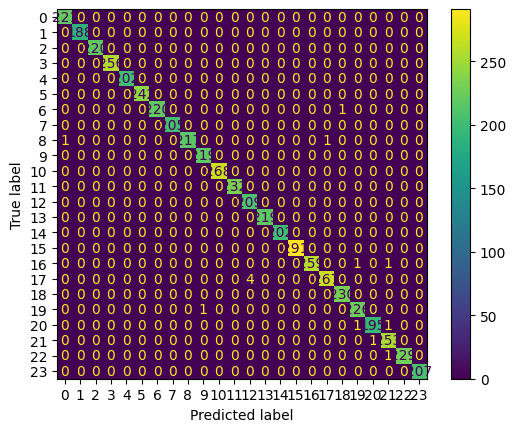

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()